In [1]:
import pandas as pd
from datasets import Dataset
from transformers import GPT2Tokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers.utils.notebook import NotebookProgressCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import torch
import matplotlib.pyplot as plt
import time

# GPU check
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")

# Ensure reproducibility across runs
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4080


In [2]:
df = pd.read_csv("../datasets/smishing.csv")
df = df[["LABEL", "TEXT"]]
df["label"] = df["LABEL"].apply(lambda x: 0 if x == "ham" else 1)
dataset = Dataset.from_pandas(df)

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token  

model = AutoModelForSequenceClassification.from_pretrained("distilgpt2", num_labels=2)
model.config.pad_token_id = model.config.eos_token_id

You passed `num_labels=2` which is incompatible to the `id2label` map of length `1`.



Loading weights:   0%|                                                                                                   | 0/76 [00:00<?, ?it/s]


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████| 76/76 [00:00<00:00, 2010.48it/s]


GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
def tokenize(batch):
    return tokenizer(batch["TEXT"], padding="max_length", truncation=True)

start_time = time.time()
dataset = dataset.map(tokenize, batched=True)
end_time = time.time()

tokenize_duration = end_time - start_time

split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]
test_dataset = split["test"]


Map:   0%|                                                                                                      | 0/5971 [00:00<?, ? examples/s]


Map:  17%|██████████████▉                                                                          | 1000/5971 [00:00<00:01, 4958.42 examples/s]


Map:  33%|█████████████████████████████▊                                                           | 2000/5971 [00:00<00:00, 6723.69 examples/s]


Map:  67%|███████████████████████████████████████████████████████████▌                             | 4000/5971 [00:00<00:00, 9043.79 examples/s]


Map: 100%|████████████████████████████████████████████████████████████████████████████████████████| 5971/5971 [00:00<00:00, 10159.80 examples/s]


Map: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 5971/5971 [00:00<00:00, 9013.36 examples/s]

In [5]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
training_args = TrainingArguments(
    output_dir=".checkpoints/gpt2-sms-finetuned",
    per_device_train_batch_size=8,
    num_train_epochs=3,
    fp16=True,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()
trainer.train()
end_time = time.time()

training_duration = end_time - start_time

Step,Training Loss
500,0.160951
1000,0.048507
1500,0.021023



Writing model shards:   0%|                                                                                               | 0/1 [00:00<?, ?it/s]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.57s/it]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.57s/it]


Writing model shards:   0%|                                                                                               | 0/1 [00:00<?, ?it/s]

...


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.47s/it]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.47s/it]


Writing model shards:   0%|                                                                                               | 0/1 [00:00<?, ?it/s]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.54s/it]


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.54s/it]

In [7]:
# evaluate() without prior train() requires this
trainer.remove_callback(NotebookProgressCallback)
metrics = trainer.evaluate()
print("\nmetrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print(f"tokenize_runtime: {tokenize_duration:.2f}s ({tokenize_duration/60:.2f}min)")
print(f"train_runtime: {training_duration:.2f}s ({training_duration/60:.2f}min)")


metrics:
eval_loss: 0.0593
eval_accuracy: 0.9916
eval_f1: 0.9787
eval_precision: 0.9705
eval_recall: 0.9871
eval_runtime: 5.5263
eval_samples_per_second: 216.2380
eval_steps_per_second: 27.1430
epoch: 3.0000
tokenize_runtime: 0.85s (0.01min)
train_runtime: 233.26s (3.89min)


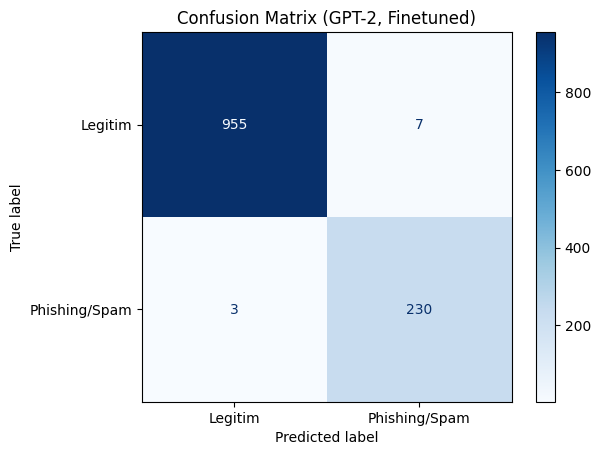

In [8]:
# confusion matrix
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitim", "Phishing/Spam"])

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (GPT-2, Finetuned)")
plt.show()

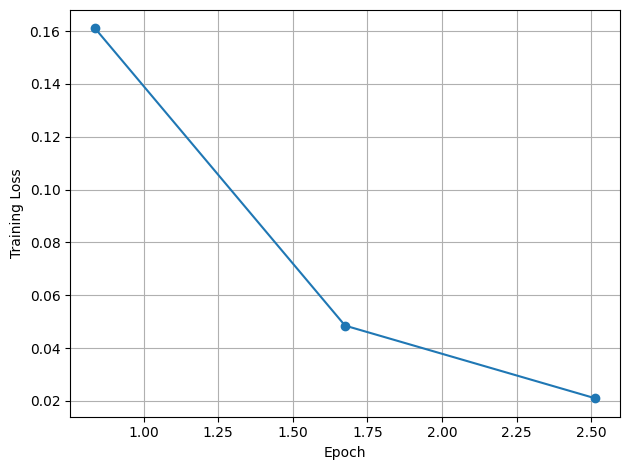

In [9]:
# loss curve
logs = trainer.state.log_history
epoch_logs = [log for log in logs if "loss" in log and "epoch" in log]
df = pd.DataFrame(epoch_logs)

plt.plot(df["epoch"], df["loss"], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()